In [2]:
# --- Step 1: Setup & Imports ---
import torch
import numpy as np
import h5py
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from scipy.interpolate import interp1d

# include .. in the path
import sys
import os

sys.path.insert(0, "..")


# Import your custom classes
from gpy_dla_detection.learn_qso_model import QSOLoader, SpectrumProcessor, GaussianProcessModel, Trainer
from gpy_dla_detection.objective import objective
from gpy_dla_detection.voigt import transition_wavelengths as all_transition_wavelengths
from gpy_dla_detection.voigt import oscillator_strengths as all_oscillator_strengths
from gpy_dla_detection.learn_qso_model import compute_pca

import torch

# Select device (CUDA if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(torch.cuda.is_available())  # Should return True if GPU is enabled
print(torch.cuda.device_count())  # Number of GPUs available
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))  # GPU model name

Using device: cpu
False
0


In [6]:

# --- Step 2: Load Quasar Spectra using QSOLoader ---
catalog_file = "../data/dr12q/processed//catalog.mat"
preloaded_file = "../data/dr12q/processed/preloaded_qsos.mat"

qso_loader = QSOLoader(catalog_file, preloaded_file, z_range=(3.0, 4.25), min_snr=5.0, max_spectra=1000)
fluxes, wavelengths, noise_variances, z_qsos = qso_loader.load_data()

print(f"Loaded {len(fluxes)} spectra.")


Total available spectra: 297301


Loading spectra:  15%|█▍        | 43766/297301 [00:20<01:58, 2135.52spec/s]

Loaded 1000 high-SNR spectra.
Loaded 1000 spectra.


In [7]:
import torch
import numpy as np

# --- Step 1: Initialize Spectrum Processor ---
spectrum_processor = SpectrumProcessor(min_lambda=911, max_lambda=1216, num_pixels=1000, 
                                       norm_min_lambda=900, norm_max_lambda=1200, max_noise_variance=9.0)

# --- Step 2: Normalize Spectra ---
norm_fluxes, norm_noise_variances, all_rest_wavelengths = spectrum_processor.normalize_spectra(
    wavelengths, fluxes, noise_variances, z_qsos=z_qsos
)

# --- Step 3: Mask Noisy Pixels BEFORE Interpolation ---
masked_fluxes, masked_noise_variances = spectrum_processor.mask_noisy_pixels(norm_fluxes, norm_noise_variances)

# --- Step 4: Interpolate onto Common Rest-Frame Grid ---
fluxes_interpolated, noise_variances_interpolated, all_rest_wavelengths = spectrum_processor.interpolate_spectra(
    all_rest_wavelengths, masked_fluxes, masked_noise_variances
)

# --- Step 5: Fill in NaNs with Median BEFORE Deforesting ---
fluxes_interpolated = spectrum_processor.fill_nan_with_median(fluxes_interpolated)

# --- Step 6: Deforest the Spectra ---
deforest_fluxes, deforest_noise_variance = spectrum_processor.de_forest_spectra(
    all_rest_wavelengths, fluxes_interpolated, noise_variances_interpolated, z_qsos=z_qsos
)

# --- Step 7: Center the Flux for GP Training ---
centered_fluxes, mu = spectrum_processor.center_fluxes(deforest_fluxes, deforest_noise_variance)

# --- Step 4: Remove Spectra with Any NaNs ---
centered_fluxes, deforest_noise_variance, all_rest_wavelengths, z_qsos = spectrum_processor.remove_nan_spectra(
    centered_fluxes, deforest_noise_variance, all_rest_wavelengths, z_qsos
)

# --- Step 8: Convert to Single NumPy Arrays Before Tensor Conversion ---
fluxes_np = np.array(centered_fluxes, dtype=np.float32)
noise_variances_np = np.array(deforest_noise_variance, dtype=np.float32)
z_qsos_np = np.array(z_qsos, dtype=np.float32)[:, None]  # Ensure correct shape

# --- Step 9: Convert to Torch Tensors ---
fluxes_tensor = torch.from_numpy(fluxes_np).to(device)
noise_variances_tensor = torch.from_numpy(noise_variances_np).to(device)
z_qsos_tensor = torch.from_numpy(z_qsos_np).to(device)

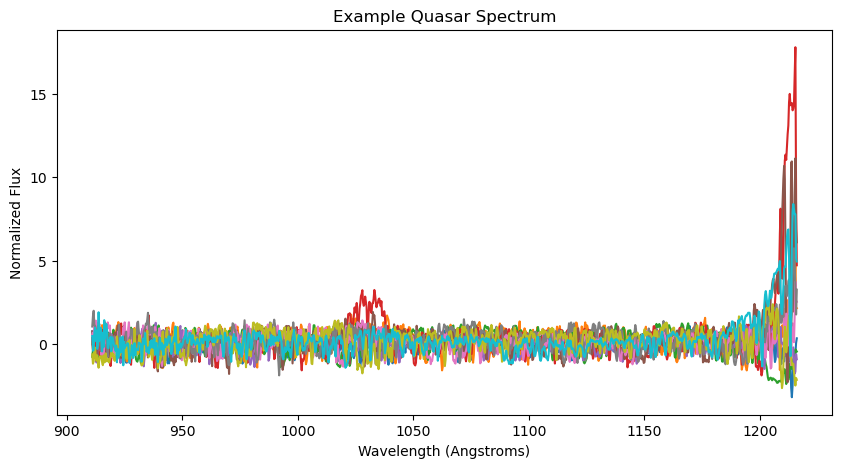

In [8]:
# visualize the spectra
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.plot(spectrum_processor.rest_wavelengths, fluxes_tensor[i])
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Normalized Flux")
plt.title("Example Quasar Spectrum")
plt.show()

In [10]:
from gpy_dla_detection.voigt import transition_wavelengths as all_transition_wavelengths
from gpy_dla_detection.voigt import oscillator_strengths as all_oscillator_strengths

# --- Step 4: Train the GP Model ---
num_pixels = 1000  # Match rest-wavelength grid
num_pca_components = 10

# compute PCA components and eigenspectra
coefficients, latent = compute_pca(fluxes_tensor, num_pca_components)
initial_M = coefficients[:, :num_pca_components] * np.sqrt(latent[:num_pca_components])  # Broadcasting happens automatically

model = GaussianProcessModel(num_pixels, num_pca_components, centered_fluxes).to(device)

# Compute Lyα redshift grid for training
all_transition_wavelengths = torch.tensor(all_transition_wavelengths, dtype=torch.float32)
all_oscillator_strengths = torch.tensor(all_oscillator_strengths, dtype=torch.float32)

lya_wavelength = all_transition_wavelengths[0] * 1e8 # Angstroms
lya_1pz = 1 + (( (1 + z_qsos_tensor) * model.rest_wavelengths.unsqueeze(0)) - lya_wavelength) / lya_wavelength

# Define optimizer and trainer # 40 mins for LBFGS
trainer = Trainer(
    model, optimizer_type="adam", learning_rate=0.005, batch_size=500,
    scheduler_type="cosine", scheduler_params={"T_max": 50, "eta_min": 1e-5}
)
num_epochs = 50

print("Before calling objective:")
print("all_transition_wavelengths shape:", all_transition_wavelengths.shape)  # Should be (31,)
print("all_oscillator_strengths shape:", all_oscillator_strengths.shape)  # Should also be (31,)

# Compute initial loss
initial_loss = objective(model, fluxes_tensor, lya_1pz, noise_variances_tensor, 10,
                         all_transition_wavelengths, all_oscillator_strengths, z_qsos_tensor).item()
print("After calling objective:")
print("all_transition_wavelengths shape:", all_transition_wavelengths.shape)
print("all_oscillator_strengths shape:", all_oscillator_strengths.shape)
# Train the model
trainer.train(fluxes_tensor, lya_1pz, noise_variances_tensor, z_qsos_tensor, 10, 
              all_transition_wavelengths, all_oscillator_strengths, max_epochs=num_epochs)


Before calling objective:
all_transition_wavelengths shape: torch.Size([31])
all_oscillator_strengths shape: torch.Size([31])
After calling objective:
all_transition_wavelengths shape: torch.Size([31])
all_oscillator_strengths shape: torch.Size([31])
Epoch 0: Loss = 660103.375, Learning Rate = 0.004995
Epoch 0: log_beta = 1.2964659658097781, log_tau_0 = -5.99760202812618
Epoch 10: Loss = 468695.1875, Learning Rate = 0.004427
Epoch 10: log_beta = 1.3790854394166936, log_tau_0 = -5.910837304074638
Epoch 20: Loss = 452669.515625, Learning Rate = 0.003125
Epoch 20: log_beta = 1.3968478991992879, log_tau_0 = -5.867746512743262
Epoch 30: Loss = 445605.9375, Learning Rate = 0.001587
Epoch 30: log_beta = 1.3860457458638202, log_tau_0 = -5.850618337378385
Epoch 40: Loss = 442620.78125, Learning Rate = 0.000398
Epoch 40: log_beta = 1.380538974194343, log_tau_0 = -5.843464969449389
Final Loss: 437369.8125


In [11]:
print("Min flux:", fluxes_tensor.min().item(), "Max flux:", fluxes_tensor.max().item())
print("Min noise:", noise_variances_tensor.min().item(), "Max noise:", noise_variances_tensor.max().item())
print("Min lya_1pz:", lya_1pz.min().item(), "Max lya_1pz:", lya_1pz.max().item())
print("Min z_qsos:", z_qsos_tensor.min().item(), "Max z_qsos:", z_qsos_tensor.max().item())

Min flux: -44.532344818115234 Max flux: 62.5523681640625
Min noise: 2.3780748961144127e-05 Max noise: 25.06258773803711
Min lya_1pz: 2.9975240230560303 Max lya_1pz: 5.235079288482666
Min z_qsos: 3.0 Max z_qsos: 4.233658790588379


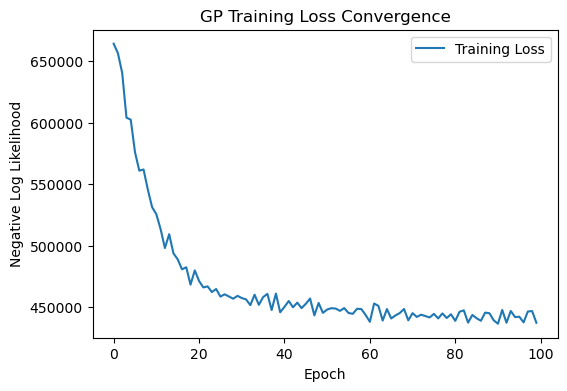

In [12]:

# --- Step 5: Evaluate & Visualize Predictions ---
loss_history = trainer.loss_history

# Plot loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history, label="Training Loss", color='C0')
plt.xlabel("Epoch")
plt.ylabel("Negative Log Likelihood")
plt.title("GP Training Loss Convergence")
plt.legend()
plt.show()


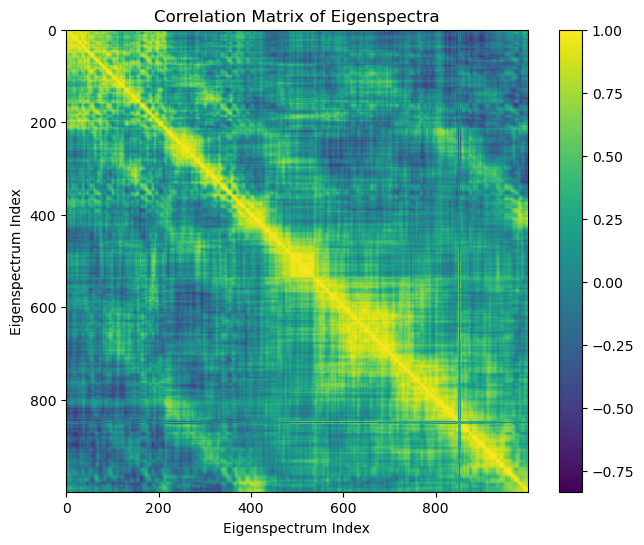

In [13]:
M = model.M.detach().numpy()
# make the covariance
K = np.dot(M, M.T)
# make the correlation matrix
C = K / np.sqrt(np.outer(np.diag(K), np.diag(K)))

# plot the correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(C, cmap='viridis')
plt.colorbar()
plt.title("Correlation Matrix of Eigenspectra")
plt.xlabel("Eigenspectrum Index")
plt.ylabel("Eigenspectrum Index")
plt.show()

(-1.0, 5.0)

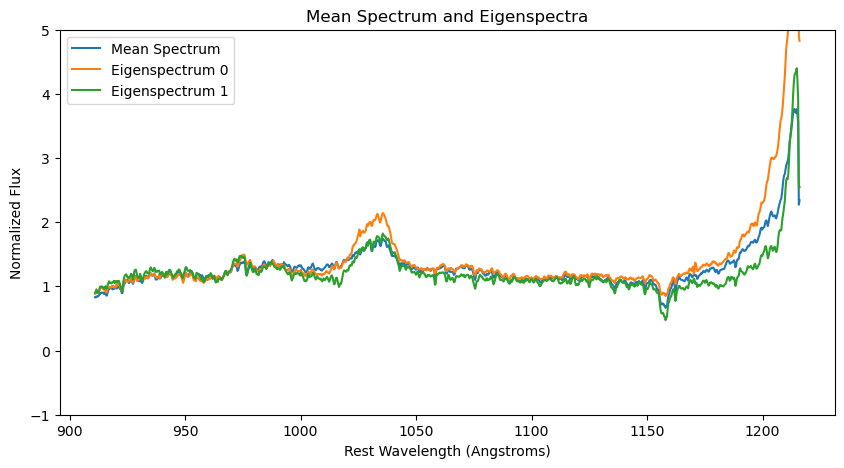

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(model.rest_wavelengths, mu, label="Mean Spectrum")
for i in range(2):
    plt.plot(model.rest_wavelengths, M[:, i] + mu, label=f"Eigenspectrum {i}")

plt.xlabel("Rest Wavelength (Angstroms)")
plt.ylabel("Normalized Flux")
plt.title("Mean Spectrum and Eigenspectra")
plt.legend()
plt.ylim(-1, 5)


In [15]:
import matplotlib.pyplot as plt

# Select a random spectrum to test conditional GP prediction
idx = np.random.randint(0, len(fluxes_tensor))
observed_flux = fluxes_tensor[idx].unsqueeze(0)  # Shape (1, num_pixels)
observed_wavelengths = model.rest_wavelengths.unsqueeze(0)  # Shape (1, num_pixels)
noise_var = noise_variances_tensor[idx].unsqueeze(0)

# Generate a set of new wavelengths (e.g., drop 30% of original points)
mask = np.random.rand(observed_wavelengths.shape[1]) > 0.3  # Keep 70% of points
new_wavelengths = observed_wavelengths[:, mask]  # Simulate missing data

# Make GP predictions
model.eval()
with torch.no_grad():
    pred_flux, pred_var = model.predict_flux(observed_wavelengths, observed_flux, noise_var, new_wavelengths, 
                                             all_transition_wavelengths, all_oscillator_strengths, z_qsos_tensor[idx])

# Compute prediction uncertainty
pred_std = torch.sqrt(pred_var)

# --- Visualization ---
plt.figure(figsize=(8, 5))
plt.fill_between(new_wavelengths.cpu().numpy().flatten(), 
                 pred_flux.cpu().numpy().flatten() - 2 * pred_std.cpu().numpy().flatten(), 
                 pred_flux.cpu().numpy().flatten() + 2 * pred_std.cpu().numpy().flatten(), 
                 color='lightblue', alpha=0.5, label="GP 2σ confidence")

plt.plot(new_wavelengths.cpu().numpy().flatten(), pred_flux.cpu().numpy().flatten(), 'b-', label="GP Mean Prediction")
plt.scatter(observed_wavelengths.cpu().numpy().flatten(), observed_flux.cpu().numpy().flatten(), color='red', s=10, alpha=0.5, label="Observed Flux")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.legend()
plt.title("GP Prediction vs True Flux (Simulated Missing Data)")
plt.show()

IndexError: tensors used as indices must be long, int, byte or bool tensors

In [16]:
M.shape

(1000, 10)